# Final Paper Claim Verification

**Mode:** immutable-run audit and paper-number reproduction.

This notebook is the executable companion to the manuscript. It locates the final Kaggle
archive, verifies every manifest-bound artifact, reconstructs all test predictions, recomputes
the headline metrics and primary statistical comparisons, displays every sensitivity table used
in the paper, and regenerates all nine manuscript figures.

The numerical source of truth is run **`20260810T103436161252Z`**. The full training run is
preserved in `01_event_timeraf_kaggle_pipeline.ipynb`; this notebook is designed for a shorter
live verification run and does not retrain XGBoost or redownload Chronos-Bolt.

## 1. Setup and locate the immutable run

In [1]:
import hashlib
import importlib.util
import json
import os
import re
import subprocess
import sys
import zipfile
from io import BytesIO
from pathlib import Path, PurePosixPath

required = {
    'matplotlib': 'matplotlib', 'numpy': 'numpy', 'pandas': 'pandas',
    'pyarrow': 'pyarrow', 'seaborn': 'seaborn', 'yaml': 'pyyaml',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, SVG, display

EXPECTED_RUN_ID = '20260810T103436161252Z'
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)

def has_project_source(path: Path) -> bool:
    return (path / 'src' / 'event_timeraf' / 'evaluation.py').exists()

def find_project_root() -> Path:
    override = os.environ.get('PROJECT_ROOT_OVERRIDE')
    candidates = [Path(override)] if override else []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in candidates:
        if candidate and has_project_source(candidate):
            return candidate.resolve()
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        source = next(kaggle_input.rglob('src/event_timeraf/evaluation.py'), None)
        if source is not None:
            return source.parents[2]
    raise FileNotFoundError('Attach the repository ZIP or set PROJECT_ROOT_OVERRIDE.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

def inspect_run_archive(path: Path):
    try:
        with zipfile.ZipFile(path) as bundle:
            manifests = [PurePosixPath(name) for name in bundle.namelist() if name.endswith('/logs/run_manifest.json')]
            for member in manifests:
                manifest = json.loads(bundle.read(member.as_posix()))
                if manifest.get('run_id') == EXPECTED_RUN_ID:
                    return member.parents[1].as_posix().rstrip('/') + '/', manifest
    except (zipfile.BadZipFile, KeyError, json.JSONDecodeError):
        pass
    return None

def find_final_archive():
    override = os.environ.get('FINAL_RUN_ZIP_OVERRIDE')
    candidates = [Path(override)] if override else []
    candidates.extend([
        PROJECT_ROOT / f'event_timeraf_final_run_{EXPECTED_RUN_ID}.zip',
        PROJECT_ROOT / 'event_timeraf_final_run.zip',
    ])
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(sorted(kaggle_input.rglob('event_timeraf_final_run*.zip')))
        candidates.extend(sorted(kaggle_input.rglob('*.zip')))
    seen = set()
    for candidate in candidates:
        if not candidate or not candidate.exists() or candidate.resolve() in seen:
            continue
        seen.add(candidate.resolve())
        inspected = inspect_run_archive(candidate)
        if inspected is not None:
            prefix, manifest = inspected
            return candidate.resolve(), prefix, manifest
    raise FileNotFoundError(f'Final archive for run {EXPECTED_RUN_ID} was not found.')

FINAL_RUN_ZIP, ARCHIVE_PREFIX, manifest = find_final_archive()
OUTPUT_ROOT = (
    Path('/kaggle/working/event_timeraf_verification')
    if Path('/kaggle/working').exists() else PROJECT_ROOT / 'verification_outputs'
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

class ArtifactStore:
    def __init__(self, archive: Path, prefix: str):
        self.archive = archive
        self.prefix = prefix

    def read_bytes(self, relative: str) -> bytes:
        with zipfile.ZipFile(self.archive) as bundle:
            return bundle.read(self.prefix + relative.lstrip('/'))

    def read_json(self, relative: str):
        return json.loads(self.read_bytes(relative).decode('utf-8'))

    def read_csv(self, relative: str) -> pd.DataFrame:
        return pd.read_csv(BytesIO(self.read_bytes(relative)))

    def read_parquet(self, relative: str) -> pd.DataFrame:
        return pd.read_parquet(BytesIO(self.read_bytes(relative)))

    def read_npz(self, relative: str):
        return np.load(BytesIO(self.read_bytes(relative)))

store = ArtifactStore(FINAL_RUN_ZIP, ARCHIVE_PREFIX)
print({'project_root': str(PROJECT_ROOT), 'archive': str(FINAL_RUN_ZIP),
       'archive_prefix': ARCHIVE_PREFIX, 'run_id': manifest['run_id']})

{'project_root': 'D:\\1.msc\\ASA', 'archive': 'D:\\1.msc\\ASA\\event_timeraf_final_run_20260810T103436161252Z.zip', 'archive_prefix': '20260810T103436161252Z/', 'run_id': '20260810T103436161252Z'}


## 2. Verify run identity, final-mode gates, and all hashes

In [2]:
audit = store.read_json('audit/data_audit.json')
tsfm_status = store.read_json('logs/tsfm_gate_status.json')

def archived_relative(logical_path: str) -> str:
    marker = f"outputs/{manifest['run_id']}/"
    if not logical_path.startswith(marker):
        raise ValueError(f'Unexpected manifest path: {logical_path}')
    return logical_path[len(marker):]

integrity_rows = []
for logical_path, expected in manifest['artifacts'].items():
    if logical_path == 'configs/default.yaml':
        payload = (PROJECT_ROOT / logical_path).read_bytes()
    else:
        payload = store.read_bytes(archived_relative(logical_path))
    integrity_rows.append({
        'artifact': logical_path,
        'bytes_match': len(payload) == expected['bytes'],
        'sha256_match': hashlib.sha256(payload).hexdigest() == expected['sha256'],
    })
integrity = pd.DataFrame(integrity_rows)
display(integrity[['bytes_match', 'sha256_match']].value_counts().rename('artifact_count').to_frame())

required_options = {
    'run_tsf_model': True,
    'final_experiment': True,
    'retrieval_evidence_reviewed': True,
    'run_stride_feature_model_sweep': True,
}
gate_rows = [{'gate': name, 'observed': manifest['run_options'].get(name), 'expected': value}
             for name, value in required_options.items()]
gate_rows.extend([
    {'gate': 'TSFM completed', 'observed': tsfm_status['completed'], 'expected': True},
    {'gate': 'Core data ready', 'observed': audit['core_ready'], 'expected': True},
    {'gate': 'Event data ready', 'observed': audit['event_ready'], 'expected': True},
])
gates = pd.DataFrame(gate_rows)
gates['match'] = gates['observed'] == gates['expected']
display(gates)

assert manifest['run_id'] == EXPECTED_RUN_ID
assert integrity[['bytes_match', 'sha256_match']].all().all()
assert gates['match'].all()
assert manifest['config_sha256'] == hashlib.sha256((PROJECT_ROOT / 'configs/default.yaml').read_bytes()).hexdigest()
print(f"Verified {len(integrity)}/{len(integrity)} manifest artifacts.")

,,artifact_count
bytes_match,sha256_match,
True,True,54


,gate,observed,expected,match
0,run_tsf_model,True,True,True
1,final_experiment,True,True,True
2,retrieval_evidence_reviewed,True,True,True
3,run_stride_feature_model_sweep,True,True,True
4,TSFM completed,True,True,True
5,Core data ready,True,True,True
6,Event data ready,True,True,True


Verified 54/54 manifest artifacts.


## 3. Reconstruct the evaluation population and audit the source data

In [3]:
arrays = store.read_npz('data/processed/window_arrays.npz')
window_schema = store.read_json('data/processed/window_arrays.json')
metadata = store.read_parquet('data/processed/window_metadata.parquet')
attrition = store.read_csv('tables/window_attrition.csv')

feature_names = list(window_schema['feature_names'])
feature_counts = {
    group.rstrip('_'): sum(name.startswith(group) for name in feature_names)
    for group in ('pm25_', 'weather_', 'cal_', 'event_')
}
population = pd.DataFrame([
    {'quantity': 'valid windows', 'value': len(metadata)},
    {'quantity': 'training origins', 'value': int(metadata['split'].eq('train').sum())},
    {'quantity': 'validation origins', 'value': int(metadata['split'].eq('validation').sum())},
    {'quantity': 'test origins', 'value': int(metadata['split'].eq('test').sum())},
    {'quantity': 'test points', 'value': int(metadata['split'].eq('test').sum() * arrays['y'].shape[1])},
    {'quantity': 'context features', 'value': len(feature_names)},
])
display(population)
display(pd.DataFrame([feature_counts]))
display(attrition)

source_audit = pd.DataFrame([
    {'field': 'PM2.5 observed coverage', 'value': audit['pm25_observed_coverage'], 'threshold/status': '>= 0.70'},
    {'field': 'Weather complete coverage', 'value': audit['weather_complete_coverage'], 'threshold/status': '>= 0.95'},
    {'field': 'Event days', 'value': audit['event_days'], 'threshold/status': '>= 30'},
    {'field': 'Qualifying event categories', 'value': audit['qualifying_event_categories'], 'threshold/status': '>= 2'},
    {'field': 'Strict event availability', 'value': audit['strict_event_availability'], 'threshold/status': 'retrospective caveat'},
])
display(source_audit)
print({'target': audit['selected_epa_site'], 'target_hours': audit['selected_epa_site_observed_hours'],
       'weather_station': audit['selected_weather_station'], 'event_records': sum(audit['event_categories'].values())})

assert len(metadata) == 48332
assert metadata['split'].value_counts().to_dict() == {'train': 34020, 'test': 7199, 'validation': 7113}
assert arrays['x'].shape == (48332, 168) and arrays['y'].shape == (48332, 24)
assert feature_counts == {'pm25': 23, 'weather': 14, 'cal': 9, 'event': 39}

,quantity,value
0,valid windows,48332
1,training origins,34020
2,validation origins,7113
3,test origins,7199
4,test points,172776
5,context features,85


,pm25,weather,cal,event
0,23,14,9,39


,run_id,stage,count
0,20260810T103436161252Z,epa_source_records,161998
1,20260810T103436161252Z,prepared_pm25_hours,52608
2,20260810T103436161252Z,noaa_weather_source_records,77138
3,20260810T103436161252Z,prepared_weather_hours,52608
4,20260810T103436161252Z,prepared_event_records,204
5,20260810T103436161252Z,aligned_hourly_rows,52608
6,20260810T103436161252Z,possible_forecast_origins,52417
7,20260810T103436161252Z,excluded_split_boundary,48
8,20260810T103436161252Z,missing_lookback,8
9,20260810T103436161252Z,missing_target,144


,field,value,threshold/status
0,PM2.5 observed coverage,0.999734,>= 0.70
1,Weather complete coverage,0.99424,>= 0.95
2,Event days,117,>= 30
3,Qualifying event categories,3,>= 2
4,Strict event availability,False,retrospective caveat


{'target': '06-037-COUNTY', 'target_hours': 52602, 'weather_station': '72297023129', 'event_records': 204}


## 4. Recompute every overall model metric from saved point predictions

In [4]:
from event_timeraf.evaluation import (
    diebold_mariano_test, holm_adjust, metric_values, paired_block_bootstrap_difference,
)

predictions_long = store.read_parquet('predictions/predictions.parquet')
archived_main = store.read_csv('tables/main_results.csv')

def model_arrays(model: str):
    frame = predictions_long.loc[predictions_long['model'].eq(model)].sort_values(['origin_time', 'horizon'])
    origins = frame['origin_time'].drop_duplicates().sort_values()
    actual = frame['actual'].to_numpy(dtype=float).reshape(len(origins), 24)
    prediction = frame['prediction'].to_numpy(dtype=float).reshape(len(origins), 24)
    return actual, prediction

all_models = predictions_long['model'].drop_duplicates().tolist()
recomputed_rows = []
matrices = {}
for model in all_models:
    actual, prediction = model_arrays(model)
    matrices[model] = prediction
    recomputed_rows.append({'model': model, **metric_values(actual, prediction)})
recomputed = pd.DataFrame(recomputed_rows)
actual = model_arrays(all_models[0])[0]

main_check = archived_main.merge(recomputed, on='model', suffixes=('_archived', '_recomputed'), validate='one_to_one')
for metric in ('mse', 'mae', 'rmse', 'mape', 'smape', 'r2'):
    assert np.allclose(main_check[f'{metric}_archived'], main_check[f'{metric}_recomputed'], atol=1e-5)

paper_order = [
    'C00_hour_month_climatology', 'C01_ridge_context', 'C02_calendar_retrieval',
    'C03_event_stratified_retrieval', 'M00_persistence', 'M01_daily_seasonal',
    'M02_weekly_seasonal', 'M03_xgb_pm25', 'M04_xgb_context',
    'M05_random_retrieval', 'M06_cosine_retrieval', 'M07_xgb_cosine',
    'M08_event_timeraf_no_drift', 'M09_event_timeraf_full',
    'M10_frozen_chronos', 'M11_chronos_hybrid_retrieval',
    'C10_chronos_climatology_fusion', 'C11_chronos_persistence_fusion',
]
verified_main = recomputed.set_index('model').loc[paper_order].reset_index()
display(verified_main[['model', 'mse', 'mae', 'rmse', 'r2']].round(3))
assert verified_main.sort_values('mse').iloc[0]['model'] == 'M04_xgb_context'
verified_main.to_csv(OUTPUT_ROOT / 'verified_main_results.csv', index=False)

,model,mse,mae,rmse,r2
0,C00_hour_month_climatology,36.297,4.038,6.025,0.139
1,C01_ridge_context,28.448,3.226,5.334,0.325
2,C02_calendar_retrieval,45.534,4.429,6.748,-0.080
3,C03_event_stratified_retrieval,38.428,3.924,6.199,0.089
4,M00_persistence,47.649,4.137,6.903,-0.130
5,M01_daily_seasonal,48.706,4.057,6.979,-0.155
6,M02_weekly_seasonal,65.606,5.123,8.100,-0.556
7,M03_xgb_pm25,29.949,3.368,5.473,0.290
8,M04_xgb_context,26.185,3.125,5.117,0.379
9,M05_random_retrieval,44.089,4.346,6.640,-0.046


## 5. Recompute the six pre-specified paired comparisons

In [5]:
comparisons = {
    'M04_minus_M03_weather_calendar': ('M04_xgb_context', 'M03_xgb_pm25'),
    'M09_minus_M04_full': ('M09_event_timeraf_full', 'M04_xgb_context'),
    'M09_minus_A00_events': ('M09_event_timeraf_full', 'A00_full_without_events'),
    'M11_minus_M10_retrieval_fusion': ('M11_chronos_hybrid_retrieval', 'M10_frozen_chronos'),
    'M11_minus_C10_climatology_placebo': ('M11_chronos_hybrid_retrieval', 'C10_chronos_climatology_fusion'),
    'M11_minus_C11_persistence_placebo': ('M11_chronos_hybrid_retrieval', 'C11_chronos_persistence_fusion'),
}
metric_functions = {
    'mse': lambda y, p: float(np.mean((y - p) ** 2)),
    'mae': lambda y, p: float(np.mean(np.abs(y - p))),
}
inference_rows = []
for loss, metric_fn in metric_functions.items():
    loss_rows = []
    for name, (model_a, model_b) in comparisons.items():
        row = {'comparison': name, 'metric': loss}
        row.update(paired_block_bootstrap_difference(
            actual, matrices[model_a], matrices[model_b], metric_fn,
            manifest['config']['evaluation']['bootstrap_block_hours'],
            manifest['config']['evaluation']['bootstrap_resamples'], manifest['seed'],
        ))
        row.update(diebold_mariano_test(
            actual, matrices[model_a], matrices[model_b], loss=loss,
            hac_lag=manifest['config']['evaluation']['dm_hac_lag'],
        ))
        loss_rows.append(row)
    adjusted = holm_adjust({row['comparison']: row['p_value'] for row in loss_rows})
    for row in loss_rows:
        row['holm_adjusted_p_value'] = adjusted[row['comparison']]
    inference_rows.extend(loss_rows)

verified_inference = pd.DataFrame(inference_rows)
archived_inference = store.read_csv('tables/primary_inference.csv')
check = archived_inference.merge(verified_inference, on=['comparison', 'metric'], suffixes=('_archived', '_recomputed'))
for field in ('difference', 'ci_low', 'ci_high', 'mean_difference', 'dm_statistic', 'p_value', 'holm_adjusted_p_value'):
    assert np.allclose(check[f'{field}_archived'], check[f'{field}_recomputed'], atol=1e-5)
display(verified_inference.loc[verified_inference['metric'].eq('mse'), [
    'comparison', 'difference', 'ci_low', 'ci_high', 'holm_adjusted_p_value'
]].round(6))
verified_inference.to_csv(OUTPUT_ROOT / 'verified_primary_inference.csv', index=False)

,comparison,difference,ci_low,ci_high,holm_adjusted_p_value
0,M04_minus_M03_weather_calendar,-3.764326,-7.120236,-1.708510,0.067267
1,M09_minus_M04_full,0.549674,-0.122399,1.591740,1.000000
2,M09_minus_A00_events,0.216249,-0.114224,0.634962,1.000000
3,M11_minus_M10_retrieval_fusion,-0.208747,-0.654452,0.216132,1.000000
4,M11_minus_C10_climatology_placebo,1.283029,0.693935,1.913267,0.000169
5,M11_minus_C11_persistence_placebo,-0.208747,-0.654452,0.216132,1.000000


## 6. Verify retrieval scale, event sensitivity, and TSFM controls

In [6]:
tables = {
    'k sensitivity': store.read_csv('tables/k_sensitivity_results.csv'),
    'knowledge-base stride': store.read_csv('tables/kb_stride_sensitivity.csv'),
    'feature-model stride': store.read_csv('tables/kb_stride_model_sensitivity.csv'),
    'event-weight sensitivity': store.read_csv('tables/event_weight_sensitivity.csv'),
    'event candidate composition': store.read_csv('tables/event_candidate_composition.csv'),
    'retrieval fusion controls': store.read_csv('tables/retrieval_fusion_ablation.csv'),
    'TSFM fusion validation': store.read_csv('tables/tsfm_fusion_validation.csv'),
    'TSFM interval metrics': store.read_csv('tables/tsfm_interval_metrics.csv'),
}
for name, frame in tables.items():
    print(f'\n{name.upper()}')
    display(frame.round(6))

stride_test = tables['knowledge-base stride'].query("split == 'test'")
assert set(stride_test['stride_hours']) == {1, 6, 24, 192}
assert int(stride_test.loc[stride_test['mse'].idxmin(), 'stride_hours']) == 6
assert int(tables['feature-model stride'].loc[tables['feature-model stride']['mse'].idxmin(), 'stride_hours']) == 6
assert tsfm_status['selected_fusion_weights'] == {
    'M11_chronos_hybrid_retrieval': 0.75,
    'C10_chronos_climatology_fusion': 0.75,
    'C11_chronos_persistence_fusion': 1.0,
}


K SENSITIVITY


,run_id,k,mse,mae,rmse,mape,smape,r2
0,20260810T103436161252Z,1,60.554818,4.885913,7.781698,219.737012,48.415604,-0.436060
1,20260810T103436161252Z,4,40.004347,4.009578,6.324899,209.235204,40.022825,0.051296
2,20260810T103436161252Z,8,36.243181,3.818274,6.020231,214.464796,38.268747,0.140492
3,20260810T103436161252Z,16,34.439642,3.711255,5.868530,218.861906,37.224176,0.183263



KNOWLEDGE-BASE STRIDE


,run_id,stride_hours,split,status,candidate_count,minimum_eligible_candidates,median_eligible_candidates,knowledge_base_memory_mb,runtime_seconds,topk_changed_fraction_vs_primary,mse,mae,rmse,mape,smape,r2
0,20260810T103436161252Z,192,validation,completed,191,190,191.0,0.366251,23.874669,1.0,27.782842,3.717265,5.270943,200.900306,40.588021,0.016684
1,20260810T103436161252Z,192,test,completed,191,191,191.0,0.366251,24.158768,1.0,39.037057,3.991250,6.247964,237.583575,40.019504,0.074235
2,20260810T103436161252Z,24,validation,completed,1521,1514,1521.0,2.915709,0.371287,0.0,27.496680,3.639924,5.243728,164.410666,39.989611,0.026812
3,20260810T103436161252Z,24,test,completed,1521,1521,1521.0,2.915709,0.667729,0.0,38.411121,3.921148,6.197671,211.332073,39.628679,0.089079
4,20260810T103436161252Z,6,validation,completed,5644,5618,5644.0,10.819027,34.393642,1.0,24.057144,3.364383,4.904808,156.310899,36.973166,0.148548
5,20260810T103436161252Z,6,test,completed,5644,5644,5644.0,10.819027,34.691121,1.0,34.616457,3.659562,5.883575,198.985320,36.541068,0.179070
6,20260810T103436161252Z,1,validation,completed,34020,33863,34020.0,65.212566,92.648050,1.0,24.467128,3.384057,4.946426,146.194370,37.585787,0.134037
7,20260810T103436161252Z,1,test,completed,34020,34020,34020.0,65.212566,92.937270,1.0,36.416339,3.789998,6.034595,199.401254,37.852459,0.136385



FEATURE-MODEL STRIDE


...

,run_id,method,aggregation,mse,mae,rmse,mape,smape,r2
0,20260810T103436161252Z,cosine,uniform,36.243181,3.818274,6.020231,214.464796,38.268747,0.140492
1,20260810T103436161252Z,cosine,similarity_weighted,36.232321,3.817359,6.019329,214.162826,38.257743,0.140749
2,20260810T103436161252Z,hybrid,uniform,38.411121,3.921148,6.197671,211.332073,39.628679,0.089079
3,20260810T103436161252Z,hybrid,similarity_weighted,38.405351,3.920270,6.197205,211.156304,39.622784,0.089216



TSFM FUSION VALIDATION


,run_id,fusion_model,tsfm_weight,validation_mse
0,20260810T103436161252Z,M11_chronos_hybrid_retrieval,0.00,27.496681
1,20260810T103436161252Z,M11_chronos_hybrid_retrieval,0.25,23.610224
2,20260810T103436161252Z,M11_chronos_hybrid_retrieval,0.50,21.087442
3,20260810T103436161252Z,M11_chronos_hybrid_retrieval,0.75,19.928339
4,20260810T103436161252Z,M11_chronos_hybrid_retrieval,1.00,20.132910
5,20260810T103436161252Z,C10_chronos_climatology_fusion,0.00,33.118511
6,20260810T103436161252Z,C10_chronos_climatology_fusion,0.25,26.131380
7,20260810T103436161252Z,C10_chronos_climatology_fusion,0.50,21.638071
8,20260810T103436161252Z,C10_chronos_climatology_fusion,0.75,19.638580
9,20260810T103436161252Z,C10_chronos_climatology_fusion,1.00,20.132910



TSFM INTERVAL METRICS


,run_id,model,nominal_coverage,coverage,mean_width,interval_score
0,20260810T103436161252Z,M10_frozen_chronos,0.8,0.781665,9.889892,15.453971


## 7. Verify event, drift, target-distribution, and traceability evidence

In [7]:
subset_counts = store.read_csv('tables/subset_counts.csv')
target_statistics = store.read_csv('tables/subset_target_statistics.csv')
event_results = store.read_csv('tables/event_period_results.csv')
drift_results = store.read_csv('tables/drift_period_results.csv')
drift_diagnostics = store.read_csv('tables/drift_component_diagnostics.csv')
drift_correlations = store.read_csv('tables/drift_component_correlations.csv')
explanations = store.read_parquet('evidence/explanations.parquet')
retrieval_evidence = store.read_parquet('evidence/retrieval_evidence.parquet')
drift_evidence = store.read_parquet('evidence/drift_evidence.parquet')

display(subset_counts)
display(target_statistics.round(3))
display(event_results.query("model in ['M04_xgb_context', 'M09_event_timeraf_full']")
        [['model', 'target_event_flag', 'n_origins', 'mse', 'mae']].round(3))
display(drift_results.query("model in ['M04_xgb_context', 'M09_event_timeraf_full', 'M10_frozen_chronos', 'M11_chronos_hybrid_retrieval']")
        [['model', 'drift_flag', 'n_origins', 'mse', 'mae']].round(3))
display(drift_diagnostics.round(4))
display(drift_correlations.round(4))

causal = pd.to_datetime(retrieval_evidence['candidate_target_end'], utc=True) < pd.to_datetime(retrieval_evidence['query_input_start'], utc=True)
evidence_audit = pd.DataFrame([
    {'check': 'retrieval evidence rows', 'observed': len(retrieval_evidence), 'expected': 345552},
    {'check': 'causal retrieval rows', 'observed': int(causal.sum()), 'expected': len(retrieval_evidence)},
    {'check': 'explanation records', 'observed': len(explanations), 'expected': 7199},
    {'check': 'finite diagnostic scales', 'observed': int(np.isfinite(explanations['diagnostic_uncertainty_scale']).sum()), 'expected': 7199},
])
evidence_audit['match'] = evidence_audit['observed'] == evidence_audit['expected']
display(evidence_audit)
assert evidence_audit['match'].all()
assert subset_counts.set_index('subset')['n_origins'].to_dict() == {
    'event': 532, 'non_event': 6667, 'recent_event': 637,
    'active_event': 293, 'drift': 566, 'non_drift': 6633,
}

,run_id,subset,n_origins,eligible_for_metrics
0,20260810T103436161252Z,event,532,True
1,20260810T103436161252Z,non_event,6667,True
2,20260810T103436161252Z,recent_event,637,True
3,20260810T103436161252Z,active_event,293,True
4,20260810T103436161252Z,drift,566,True
5,20260810T103436161252Z,non_drift,6633,True


,run_id,subset,n_origins,n_points,target_mean,target_std,target_variance,target_min,target_max
0,20260810T103436161252Z,all,7199,172776,10.041,6.494,42.167,0.0,161.55
1,20260810T103436161252Z,event,532,12768,7.940,4.758,22.636,0.0,19.05
2,20260810T103436161252Z,non_event,6667,160008,10.209,6.584,43.346,0.0,161.55
3,20260810T103436161252Z,recent_event,637,15288,7.333,4.282,18.334,0.0,22.40
4,20260810T103436161252Z,active_event,293,7032,10.573,3.990,15.921,0.0,19.05
5,20260810T103436161252Z,drift,566,13584,9.936,8.342,69.593,0.0,112.60
6,20260810T103436161252Z,non_drift,6633,159192,10.050,6.311,39.826,0.0,161.55


,model,target_event_flag,n_origins,mse,mae
24,M04_xgb_context,False,6667,27.520,3.179
25,M04_xgb_context,True,532,9.451,2.450
34,M09_event_timeraf_full,False,6667,27.995,3.187
35,M09_event_timeraf_full,True,532,10.932,2.613


,model,drift_flag,n_origins,mse,mae
24,M04_xgb_context,False,6633,26.060,3.086
25,M04_xgb_context,True,566,27.650,3.585
34,M09_event_timeraf_full,False,6633,26.282,3.085
35,M09_event_timeraf_full,True,566,32.039,3.833
36,M10_frozen_chronos,False,6633,28.890,3.177
37,M10_frozen_chronos,True,566,29.539,3.524
38,M11_chronos_hybrid_retrieval,False,6633,28.692,3.170
39,M11_chronos_hybrid_retrieval,True,566,29.210,3.610


,run_id,split,component,score_mode,n_origins,zero_fraction,mean,std,p50,p90,p95,max
0,20260810T103436161252Z,validation,mean_shift,upper_tail,7113,0.5245,0.0987,0.1663,0.0000,0.3325,0.4847,1.0000
1,20260810T103436161252Z,validation,variance_shift,upper_tail,7113,0.5046,0.1189,0.1926,0.0000,0.4086,0.5643,1.0000
2,20260810T103436161252Z,validation,retrieval_similarity_drop,upper_tail,7113,0.6592,0.0333,0.0653,0.0000,0.1325,0.1875,0.4732
3,20260810T103436161252Z,validation,weather_shift,upper_tail,7113,0.5945,0.0612,0.1137,0.0000,0.2157,0.3228,0.8778
4,20260810T103436161252Z,validation,event_burst,upper_tail,7113,0.9516,0.0484,0.2145,0.0000,0.0000,0.0000,1.0000
5,20260810T103436161252Z,test,mean_shift,upper_tail,7199,0.5330,0.0886,0.1608,0.0000,0.2881,0.3641,1.0000
6,20260810T103436161252Z,test,variance_shift,upper_tail,7199,0.4371,0.1213,0.1794,0.0314,0.3659,0.4803,1.0000
7,20260810T103436161252Z,test,retrieval_similarity_drop,upper_tail,7199,0.7350,0.0273,0.0624,0.0000,0.1118,0.1715,0.4787
8,20260810T103436161252Z,test,weather_shift,upper_tail,7199,0.5880,0.0536,0.1011,0.0000,0.1817,0.2621,0.8405
9,20260810T103436161252Z,test,event_burst,upper_tail,7199,0.9582,0.0418,0.2002,0.0000,0.0000,0.0000,1.0000


,run_id,split,left_component,right_component,correlation
0,20260810T103436161252Z,validation,mean_shift,variance_shift,0.4512
1,20260810T103436161252Z,validation,mean_shift,retrieval_similarity_drop,-0.1364
2,20260810T103436161252Z,validation,mean_shift,weather_shift,-0.0511
3,20260810T103436161252Z,validation,mean_shift,event_burst,0.1127
4,20260810T103436161252Z,validation,variance_shift,retrieval_similarity_drop,-0.1081
5,20260810T103436161252Z,validation,variance_shift,weather_shift,-0.0607
6,20260810T103436161252Z,validation,variance_shift,event_burst,0.2870
7,20260810T103436161252Z,validation,retrieval_similarity_drop,weather_shift,0.0420
8,20260810T103436161252Z,validation,retrieval_similarity_drop,event_burst,0.1467
9,20260810T103436161252Z,validation,weather_shift,event_burst,0.1536


,check,observed,expected,match
0,retrieval evidence rows,345552,345552,True
1,causal retrieval rows,345552,345552,True
2,explanation records,7199,7199,True
3,finite diagnostic scales,7199,7199,True


## 8. Regenerate all manuscript figures

,generated_figure
0,drift_aware_forecast_evidence_head.svg
1,drift_scores.png
2,event_timeraf_pipeline_overview.svg
3,forecast_case.png
4,leakage_safe_event_context_retriever.svg
5,mae_by_horizon.png
6,mse_by_horizon.png
7,retrieval_diagnostics.png
8,source_audited_context_builder.svg


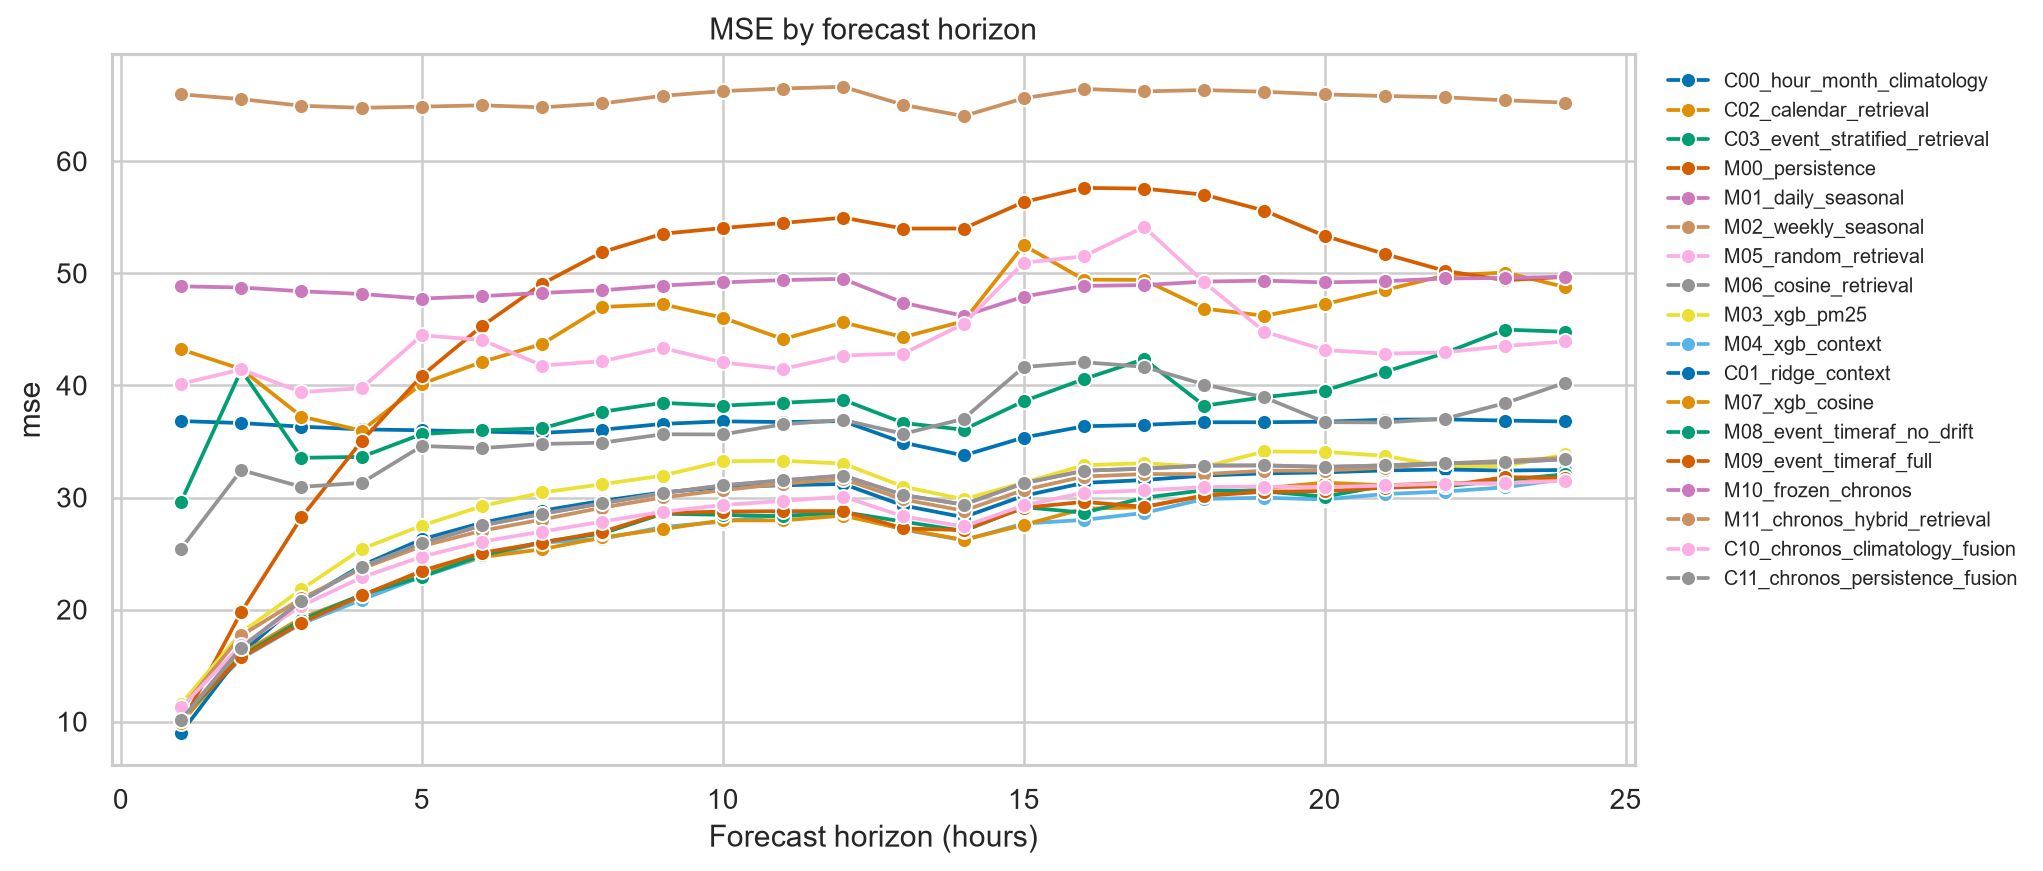

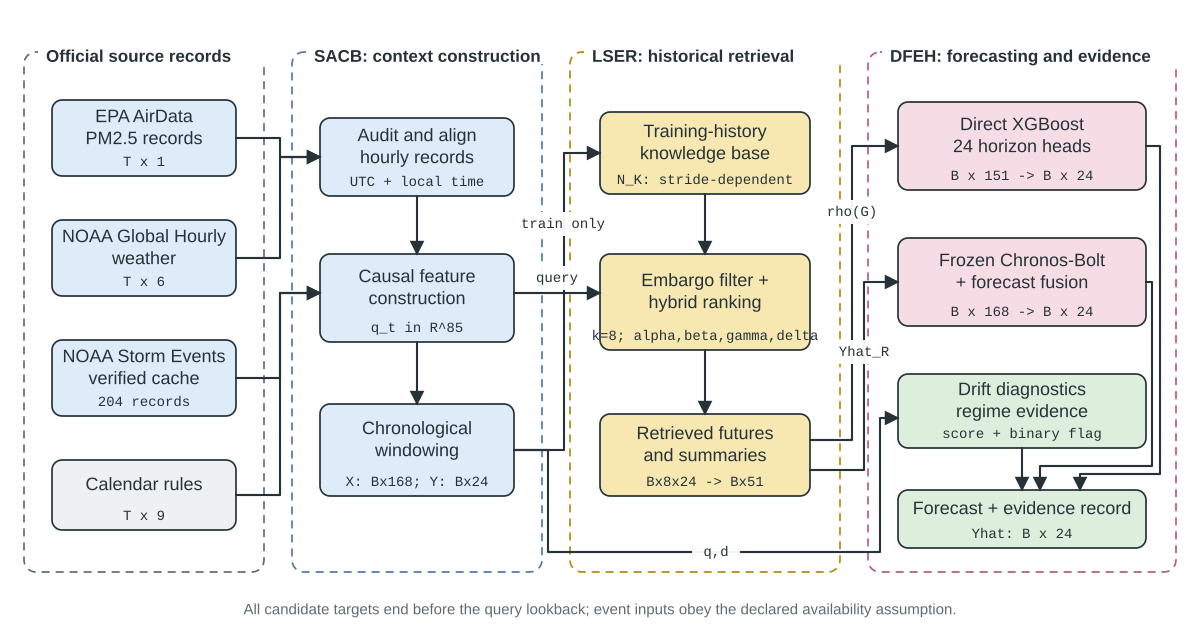

In [8]:
from event_timeraf.plots import (
    plot_drift_scores, plot_forecast_case, plot_horizon_metrics, plot_retrieval_diagnostics,
)

figure_dir = OUTPUT_ROOT / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
metrics = store.read_csv('tables/metrics.csv')
plot_models = metrics.loc[metrics['model'].str.match(r'^[MC]')]

plot_horizon_metrics(plot_models, 'mse', figure_dir / 'mse_by_horizon.png'); plt.close()
plot_horizon_metrics(plot_models, 'mae', figure_dir / 'mae_by_horizon.png'); plt.close()
plot_retrieval_diagnostics(retrieval_evidence, figure_dir / 'retrieval_diagnostics.png'); plt.close()
plot_drift_scores(drift_evidence.loc[drift_evidence['split'].eq('test')], figure_dir / 'drift_scores.png'); plt.close()

test_mask = metadata['split'].eq('test').to_numpy()
test_x = arrays['x'][test_mask]
test_y = arrays['y'][test_mask]
case_index = int(np.argsort(np.abs(
    test_y.mean(axis=1) - matrices['M09_event_timeraf_full'].mean(axis=1)
))[len(test_y) // 2])
plot_forecast_case(
    test_x[case_index], test_y[case_index],
    {
        'Persistence': matrices['M00_persistence'][case_index],
        'XGBoost context': matrices['M04_xgb_context'][case_index],
        'Event-TimeRAF': matrices['M09_event_timeraf_full'][case_index],
    },
    figure_dir / 'forecast_case.png',
); plt.close()

builder_path = PROJECT_ROOT / 'paper' / 'tools' / 'build_methodology_figures.py'
spec = importlib.util.spec_from_file_location('methodology_figures', builder_path)
methodology_figures = importlib.util.module_from_spec(spec)
spec.loader.exec_module(methodology_figures)
vector_builders = {
    'event_timeraf_pipeline_overview.svg': methodology_figures.pipeline_figure,
    'source_audited_context_builder.svg': methodology_figures.context_figure,
    'leakage_safe_event_context_retriever.svg': methodology_figures.retrieval_figure,
    'drift_aware_forecast_evidence_head.svg': methodology_figures.forecast_figure,
}
for name, builder in vector_builders.items():
    builder(figure_dir / name)

generated = sorted(path.name for path in figure_dir.iterdir() if path.is_file())
display(pd.DataFrame({'generated_figure': generated}))
assert len(generated) == 9
display(Image(filename=str(figure_dir / 'mse_by_horizon.png')))
display(SVG(filename=str(figure_dir / 'event_timeraf_pipeline_overview.svg')))

## 9. Paper claim registry and final gate

In [9]:
main = verified_main.set_index('model')
primary_mse = verified_inference.query("metric == 'mse'").set_index('comparison')
claim_registry = pd.DataFrame([
    {'claim': '48,332 windows and 7,199 test origins', 'checked_how': 'Reconstructed NPZ and metadata', 'result': 'Confirmed'},
    {'claim': 'M04 MSE/MAE/RMSE/R2 = 26.185/3.125/5.117/0.379', 'checked_how': 'Recomputed from 172,776 prediction points', 'result': 'Confirmed'},
    {'claim': 'M09 does not improve on M04', 'checked_how': 'Recomputed metrics, 2,000-block bootstrap, DM/Holm', 'result': 'Confirmed'},
    {'claim': 'M11 improves M10 conclusively', 'checked_how': 'Paired inference with 168-origin blocks and HAC lag 167', 'result': 'Corrected: unresolved'},
    {'claim': 'M11 gain is retrieval-specific', 'checked_how': 'Compared against climatology and persistence fusion controls', 'result': 'Corrected: unsupported'},
    {'claim': 'Event channel improves retrieval', 'checked_how': 'Event-weight and event-stratified sensitivity', 'result': 'Corrected: unsupported'},
    {'claim': 'All retrieval candidates satisfy the temporal embargo', 'checked_how': 'Checked all 345,552 evidence rows', 'result': 'Confirmed'},
    {'claim': 'Strict real-time event availability', 'checked_how': 'Inspected NOAA availability fields', 'result': 'Flagged unverified'},
    {'claim': 'External geographic generalization', 'checked_how': 'Dataset inventory', 'result': 'Flagged unverified'},
])
display(claim_registry)
claim_registry.to_csv(OUTPUT_ROOT / 'claim_verification.csv', index=False)

paper_sources = [PROJECT_ROOT / 'paper' / 'main.tex', PROJECT_ROOT / 'paper' / 'main_humanized.tex']
paper_text = '\n'.join(path.read_text(encoding='utf-8') for path in paper_sources)
source_gate = {
    'final_run_id_present': EXPECTED_RUN_ID in paper_text,
    'old_run_id_absent': '20260723T112033170131Z' not in paper_text,
    'old_sparse_kb_claim_absent': '191 non-overlapping' not in paper_text,
    'old_bootstrap_claim_absent': '500 paired' not in paper_text and '500-resample' not in paper_text,
    'strict_realtime_not_claimed': 'strict real-time forecasts' not in paper_text,
}
display(pd.DataFrame([source_gate]))
assert all(source_gate.values())

numeric_gate = {
    'M04_best': main['mse'].idxmin() == 'M04_xgb_context',
    'M09_worse_than_M04': main.loc['M09_event_timeraf_full', 'mse'] > main.loc['M04_xgb_context', 'mse'],
    'M11_vs_M10_unresolved': primary_mse.loc['M11_minus_M10_retrieval_fusion', 'ci_low'] < 0 < primary_mse.loc['M11_minus_M10_retrieval_fusion', 'ci_high'],
    'M11_worse_than_climatology_fusion': primary_mse.loc['M11_minus_C10_climatology_placebo', 'ci_low'] > 0,
    'all_hashes_verified': bool(integrity[['bytes_match', 'sha256_match']].all().all()),
    'all_figures_generated': len(generated) == 9,
}
display(pd.DataFrame([numeric_gate]))
assert all(numeric_gate.values())
print('FINAL VERIFICATION STATUS: PASS WITH EXPLICIT LIMITATIONS')

,claim,checked_how,result
0,"48,332 windows and 7,199 test origins",Reconstructed NPZ and metadata,Confirmed
1,M04 MSE/MAE/RMSE/R2 = 26.185/3.125/5.117/0.379,"Recomputed from 172,776 prediction points",Confirmed
2,M09 does not improve on M04,"Recomputed metrics, 2,000-block bootstrap, DM/...",Confirmed
3,M11 improves M10 conclusively,Paired inference with 168-origin blocks and HA...,Corrected: unresolved
4,M11 gain is retrieval-specific,Compared against climatology and persistence f...,Corrected: unsupported
5,Event channel improves retrieval,Event-weight and event-stratified sensitivity,Corrected: unsupported
6,All retrieval candidates satisfy the temporal ...,"Checked all 345,552 evidence rows",Confirmed
7,Strict real-time event availability,Inspected NOAA availability fields,Flagged unverified
8,External geographic generalization,Dataset inventory,Flagged unverified


,final_run_id_present,old_run_id_absent,old_sparse_kb_claim_absent,old_bootstrap_claim_absent,strict_realtime_not_claimed
0,True,True,True,True,True


,M04_best,M09_worse_than_M04,M11_vs_M10_unresolved,M11_worse_than_climatology_fusion,all_hashes_verified,all_figures_generated
0,True,True,True,True,True,True


FINAL VERIFICATION STATUS: PASS WITH EXPLICIT LIMITATIONS


## Takeaways

1. M04 XGBoost context is the strongest evaluated model; M09 does not improve it.
2. Denser retrieval materially improves the retrieval-only path, but does not make the full feature model best.
3. M11 versus frozen Chronos-Bolt is statistically unresolved and M11 is significantly worse than the climatology fusion control on MSE.
4. Increasing event weight changes retrieved candidates, but degrades rather than improves the tested retrieval forecast.
5. Event timing remains retrospective, and geographic generalization remains unverified.